# Standard Model Review

Use this notebook to load a trained standard SCVI model from an experiment folder, apply it to the AnnData object, and make quick plots to judge whether the baseline already looks good.

In [12]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import scvi
import pandas as pd
from scipy import sparse
from scipy.stats import pearsonr
from itertools import combinations

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from config import ADATA_PATH, DEFAULT_EXPERIMENT_NAME, EVAL_RANDOM_SEED, GFF_PATH, OPERON_TSV
from experiment_utils import build_experiment_paths
from scvi.model import SCVI as StandardSCVI
from operon_aware_lib import build_gene_to_idx, load_operons

plt.style.use('default')
np.random.seed(EVAL_RANDOM_SEED)

In [13]:
# Change this if your standard model lives in a different experiment folder.
EXPERIMENT_NAME = DEFAULT_EXPERIMENT_NAME

model_path = "../Results/experiments/baseline_shared/models/standard"
adata_path = os.path.join(ROOT, ADATA_PATH) if not os.path.isabs(ADATA_PATH) else ADATA_PATH

print('Experiment:', EXPERIMENT_NAME)
print('Model path :', model_path)
print('AnnData    :', adata_path)

Experiment: corr_log1p_lambda0p5
Model path : ../Results/experiments/baseline_shared/models/standard
AnnData    : /home/mmonshiz/SingleCell/pountain_data/outputs/lb_adata.h5ad


In [14]:
adata = sc.read_h5ad(adata_path)
scvi.data.setup_anndata(adata)
model = StandardSCVI.load(model_path, adata=adata)

print(f'Cells: {adata.n_obs:,}')
print(f'Genes: {adata.n_vars:,}')
print(f'ELBO : {model.get_elbo():.3f}')

INFO     No batch_key inputted, assuming all cells are same batch                                                  
INFO     No label_key inputted, assuming all cells have same label                                                 
INFO     Using data from adata.X                                                                                   
INFO     Computing library size prior per batch                                                                    
INFO     Successfully registered anndata object containing 57627 cells, 3070 vars, 1 batches, 1 labels, and 0      
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               
INFO     Please do not further modify adata until model is trained.                                                
INFO     Using data from adata.X                                                                                   
INFO     Computing library size prior per batch                         

/home/mmonshiz/SingleCell/scvi-tools/scvi/model/base/_utils.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state_dict = torch.load(model_path, map_location=map_l

INFO     Registered keys:['X', 'batch_indices', 'local_l_mean', 'local_l_var', 'labels']                           
INFO     Successfully registered anndata object containing 57627 cells, 3070 vars, 1 batches, 1 labels, and 0      
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               
Cells: 57,627
Genes: 3,070
ELBO : -376.383


## 1. Latent Space

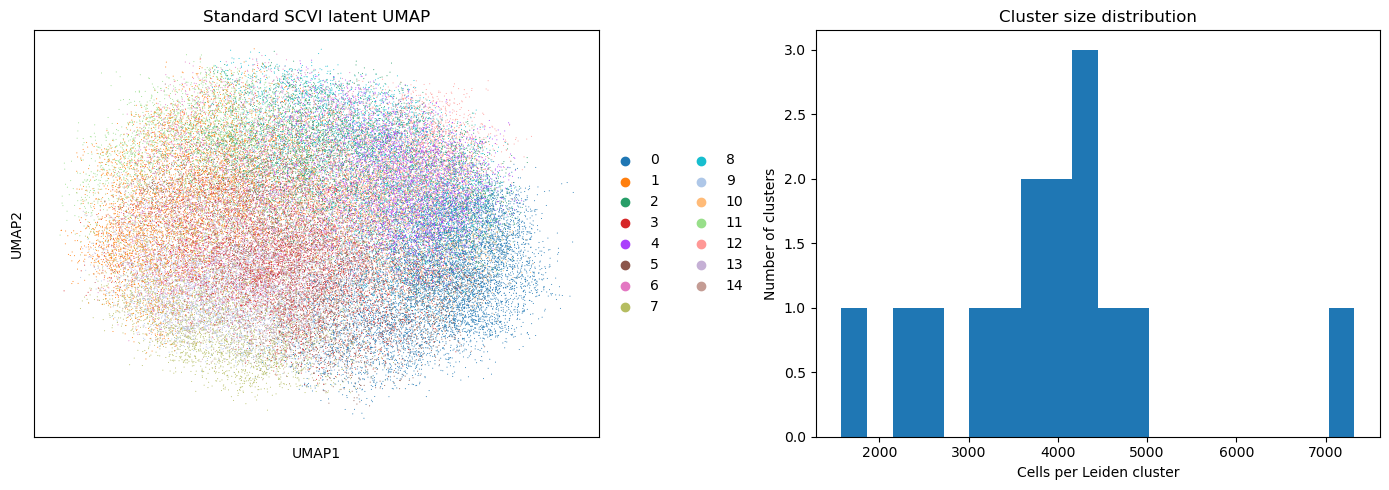

In [15]:
adata_latent = adata.copy()
adata_latent.obsm['X_scvi'] = model.get_latent_representation()
sc.pp.neighbors(adata_latent, use_rep='X_scvi', n_neighbors=15)
sc.tl.leiden(adata_latent, key_added='scvi_leiden', resolution=0.5)
sc.tl.umap(adata_latent)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(adata_latent, color='scvi_leiden', ax=axes[0], show=False, title='Standard SCVI latent UMAP')
axes[1].hist(adata_latent.obs['scvi_leiden'].value_counts().values, bins=20)
axes[1].set_title('Cluster size distribution')
axes[1].set_xlabel('Cells per Leiden cluster')
axes[1].set_ylabel('Number of clusters')
plt.tight_layout()
plt.show()

## 2. Raw vs Denoised Expression

In [16]:
adata_expr = adata.copy()


scvi.data.setup_anndata(adata_expr)
expr = model.get_normalized_expression(adata=adata_expr).values

X_raw = adata_expr.X.toarray() if sparse.issparse(adata_expr.X) else np.asarray(adata_expr.X)
raw_counts_per_cell = X_raw.sum(axis=1)
denoised_total_per_cell = expr.sum(axis=1)

raw_log = np.log1p(X_raw)
denoised_log = np.log1p(expr)
gene_var = raw_log.var(axis=0)
top_idx = np.argsort(gene_var)[-min(500, raw_log.shape[1]):]

gene_corrs = []
for j in top_idx:
    if np.std(raw_log[:, j]) < 1e-10 or np.std(denoised_log[:, j]) < 1e-10:
        continue
    gene_corrs.append(pearsonr(raw_log[:, j], denoised_log[:, j])[0])

gene_corrs = np.array(gene_corrs)
print(f'Cells used for expression plots: {adata_expr.n_obs:,}')
print(f'Median gene-wise raw vs denoised r: {np.median(gene_corrs):.4f}')

INFO     No batch_key inputted, assuming all cells are same batch                                                  
INFO     No label_key inputted, assuming all cells have same label                                                 
INFO     Using data from adata.X                                                                                   
INFO     Computing library size prior per batch                                                                    
INFO     Successfully registered anndata object containing 57627 cells, 3070 vars, 1 batches, 1 labels, and 0      
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               
INFO     Please do not further modify adata until model is trained.                                                
Cells used for expression plots: 57,627
Median gene-wise raw vs denoised r: 0.0928


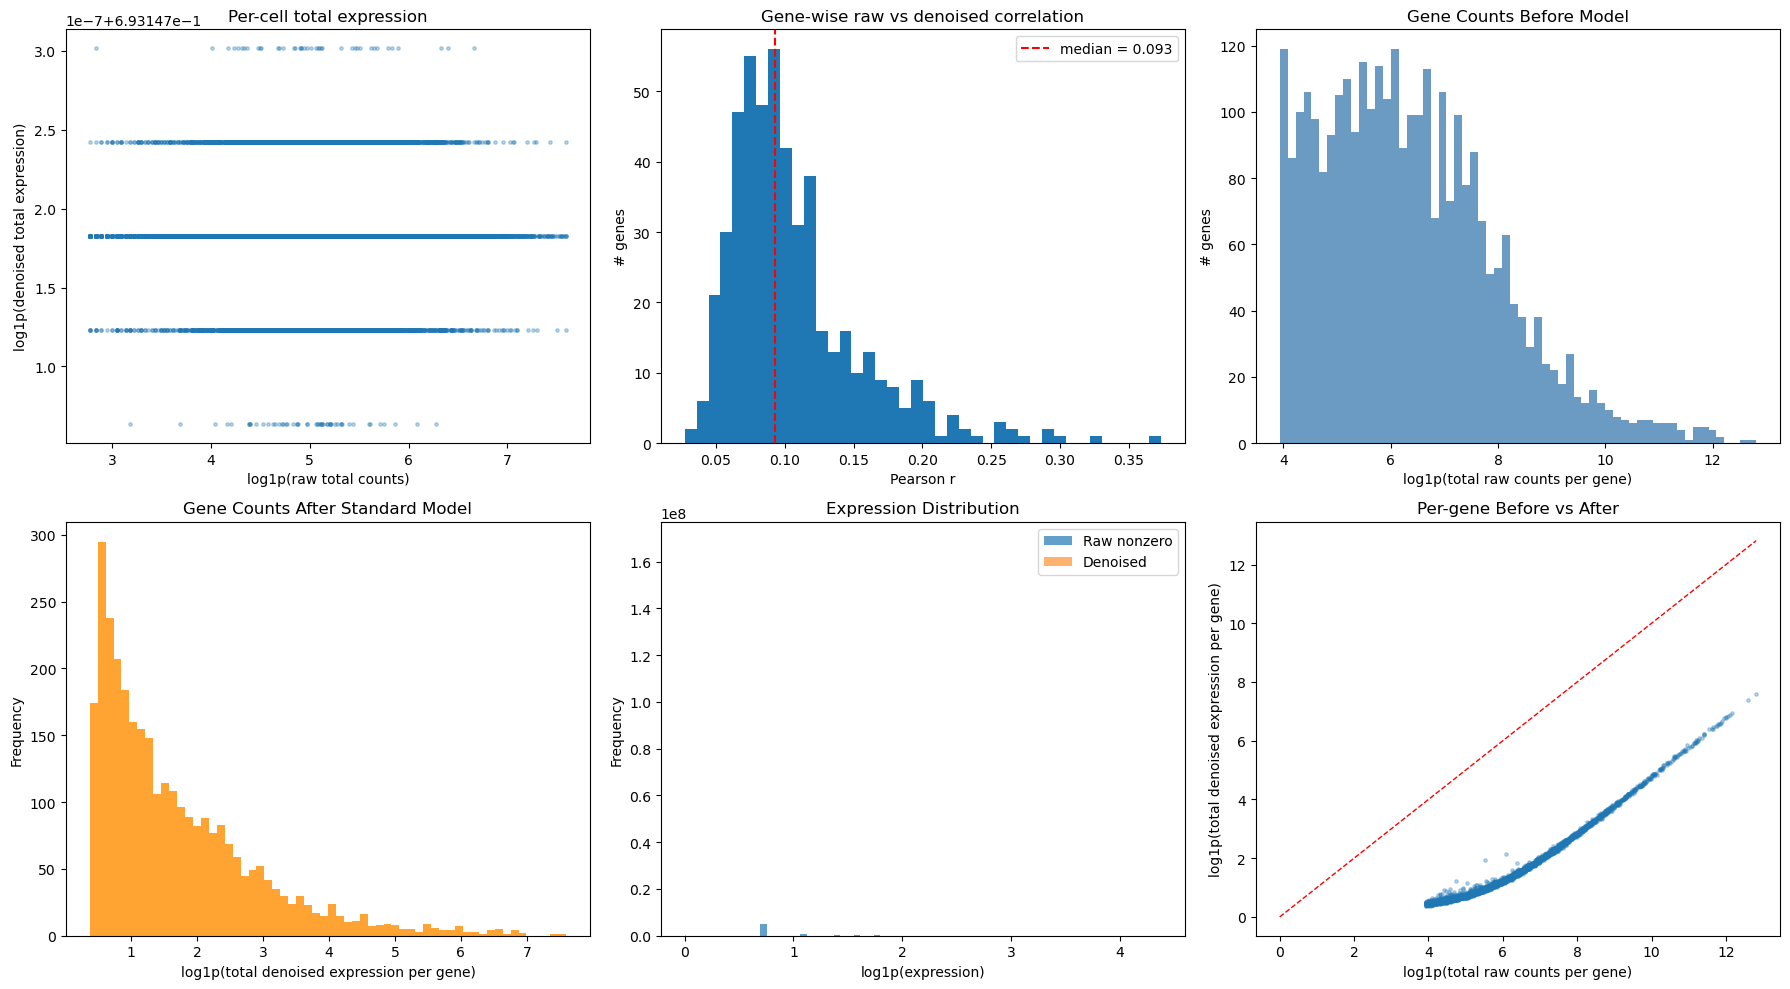

In [17]:
gene_counts_before = X_raw.sum(axis=0)
gene_counts_after = expr.sum(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].scatter(np.log1p(raw_counts_per_cell), np.log1p(denoised_total_per_cell), s=6, alpha=0.3)
axes[0, 0].set_title('Per-cell total expression')
axes[0, 0].set_xlabel('log1p(raw total counts)')
axes[0, 0].set_ylabel('log1p(denoised total expression)')

axes[0, 1].hist(gene_corrs, bins=40)
axes[0, 1].axvline(np.median(gene_corrs), color='red', linestyle='--', label=f'median = {np.median(gene_corrs):.3f}')
axes[0, 1].set_title('Gene-wise raw vs denoised correlation')
axes[0, 1].set_xlabel('Pearson r')
axes[0, 1].set_ylabel('# genes')
axes[0, 1].legend()

axes[0, 2].hist(np.log1p(gene_counts_before[gene_counts_before > 0]), bins=60, color='steelblue', alpha=0.8)
axes[0, 2].set_title('Gene Counts Before Model')
axes[0, 2].set_xlabel('log1p(total raw counts per gene)')
axes[0, 2].set_ylabel('# genes')

axes[1, 0].hist(np.log1p(gene_counts_after[gene_counts_after > 0]), bins=60, color='darkorange', alpha=0.8)
axes[1, 0].set_title('Gene Counts After Standard Model')
axes[1, 0].set_xlabel('log1p(total denoised expression per gene)')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(np.log1p(X_raw[X_raw > 0]), bins=60, alpha=0.7, label='Raw nonzero')
axes[1, 1].hist(np.log1p(expr).ravel(), bins=60, alpha=0.6, label='Denoised')
axes[1, 1].set_title('Expression Distribution')
axes[1, 1].set_xlabel('log1p(expression)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

axes[1, 2].scatter(np.log1p(gene_counts_before + 1e-8), np.log1p(gene_counts_after + 1e-8), s=6, alpha=0.3)
lims = [0, max(np.log1p(gene_counts_before + 1e-8).max(), np.log1p(gene_counts_after + 1e-8).max())]
axes[1, 2].plot(lims, lims, 'r--', linewidth=1)
axes[1, 2].set_title('Per-gene Before vs After')
axes[1, 2].set_xlabel('log1p(total raw counts per gene)')
axes[1, 2].set_ylabel('log1p(total denoised expression per gene)')

plt.tight_layout()
plt.show()

## 3. Standard-Only RegulonDB Correlations

In [18]:
gene_to_idx = build_gene_to_idx(os.path.join(ROOT, GFF_PATH), adata)
operons_valid, operons_all = load_operons(os.path.join(ROOT, OPERON_TSV), gene_to_idx)

def safe_pearsonr(a, b):
    if np.std(a) < 1e-10 or np.std(b) < 1e-10:
        return np.nan
    return pearsonr(a, b)[0]

def mean_pairwise_corr(expr_matrix, gidx):
    rs = [safe_pearsonr(expr_matrix[:, i], expr_matrix[:, j]) for i, j in combinations(gidx, 2)]
    rs = [r for r in rs if not np.isnan(r)]
    return np.mean(rs) if rs else np.nan

results = []
for _, row in operons_valid.iterrows():
    gidx = row['idx_found']
    results.append({
        'operon_name': row['operon_name'],
        'n_genes': len(gidx),
        'confidence': row['confidence_label'],
        'r_standard': mean_pairwise_corr(expr, gidx),
    })

std_operon_df = pd.DataFrame(results).dropna(subset=['r_standard']).reset_index(drop=True)
print(f'Operons with valid standard-model correlation: {len(std_operon_df):,}')
print(f'Overall mean r_standard: {std_operon_df["r_standard"].mean():.4f}')

[gene_mapping] Parsed 4464 symbol→blattner pairs from GFF
[gene_mapping] 3070/4464 symbols mapped to adata (1394 not found — likely filtered in preprocessing)
[operon_utils] Parsed 848 multi-gene operons from RegulonDB
Weak      725
NaN        62
Strong     61

[operon_utils] 560 operons with ≥2 genes in adata (2368 total gene pairs)
[operon_utils] Coverage by confidence level:
  Confirmed: 0/0 operons have ≥2 genes in adata
  Strong   : 46/61 operons have ≥2 genes in adata
  Weak     : 473/725 operons have ≥2 genes in adata
  NaN      : 41/62 operons have ≥2 genes in adata (confidence field missing or unrecognised in TSV)
Operons with valid standard-model correlation: 560
Overall mean r_standard: 0.3386


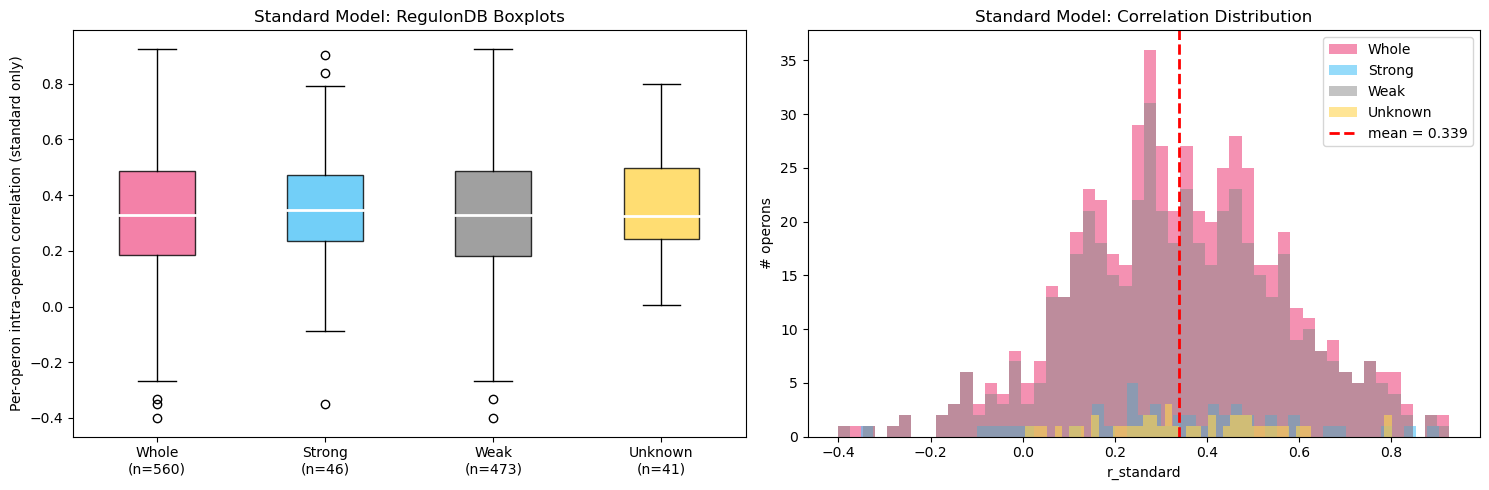

In [19]:
strong_df = std_operon_df[std_operon_df['confidence'] == 'Strong']
weak_df = std_operon_df[std_operon_df['confidence'] == 'Weak']
unknown_df = std_operon_df[std_operon_df['confidence'].isna()]

box_data = [std_operon_df['r_standard'].values]
box_labels = [f'Whole\n(n={len(std_operon_df)})']
box_colors = ['#f06292']

if len(strong_df) > 0:
    box_data.append(strong_df['r_standard'].values)
    box_labels.append(f'Strong\n(n={len(strong_df)})')
    box_colors.append('#4fc3f7')
if len(weak_df) > 0:
    box_data.append(weak_df['r_standard'].values)
    box_labels.append(f'Weak\n(n={len(weak_df)})')
    box_colors.append('#888888')
if len(unknown_df) > 0:
    box_data.append(unknown_df['r_standard'].values)
    box_labels.append(f'Unknown\n(n={len(unknown_df)})')
    box_colors.append('#ffd54f')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bp = axes[0].boxplot(box_data, patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_xticklabels(box_labels)
axes[0].set_ylabel('Per-operon intra-operon correlation (standard only)')
axes[0].set_title('Standard Model: RegulonDB Boxplots')

axes[1].hist(std_operon_df['r_standard'], bins=50, alpha=0.7, label='Whole', color='#f06292')
if len(strong_df) > 0:
    axes[1].hist(strong_df['r_standard'], bins=50, alpha=0.6, label='Strong', color='#4fc3f7')
if len(weak_df) > 0:
    axes[1].hist(weak_df['r_standard'], bins=50, alpha=0.5, label='Weak', color='#888888')
if len(unknown_df) > 0:
    axes[1].hist(unknown_df['r_standard'], bins=50, alpha=0.6, label='Unknown', color='#ffd54f')
axes[1].axvline(std_operon_df['r_standard'].mean(), color='red', linestyle='--', linewidth=2, label=f'mean = {std_operon_df["r_standard"].mean():.3f}')
axes[1].set_title('Standard Model: Correlation Distribution')
axes[1].set_xlabel('r_standard')
axes[1].set_ylabel('# operons')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Quick Interpretation Guide

Things that usually look reassuring for the standard model:
- latent UMAP shows structured clusters instead of one blurry cloud
- per-cell raw vs denoised totals have a clear positive trend
- gene-wise raw vs denoised correlations are not all near zero
- denoised expression is smoother than raw counts, but not collapsed into one narrow distribution
- the standard-only RegulonDB boxplots are not dominated by negative or near-zero correlations

If you want to compare against the operon-aware model later, you can duplicate this notebook and load `paths['model_operon']` instead.